In [10]:
!pip install mlxtend


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 6.4 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.1 MB 7.0 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.1 MB 6.9 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.1 MB 6.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/8.1 MB 6.7 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.1 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.1 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 6.2 MB/s  0:00:01
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.0 MB 6.8 MB/s eta 0:00:01
   ------------- ----------------------

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
df = pd.read_excel(r"C:\Users\ribix\Documents/BMI.xlsx")
df.head()

,Gender,Height,Weight,Index
0,Male,189,87,1
1,Male,195,81,1
2,Male,155,51,1
3,Male,191,79,1
4,Female,172,67,1


In [19]:
X = df[["Height", "Weight"]]
y = df["Index"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)



Accuracy: 0.9473684210526315


In [21]:
for i in range(len(X_test)):
    print("Test data:", X_test.iloc[i], 
          "| True label:", y_test.iloc[i], 
          "| Predicted:", y_pred[i])

    if y_test.iloc[i] == y_pred[i]:
        print("Correct prediction")
    else:
        print("Wrong prediction")


Test data: Height    156
Weight     52
Name: 40, dtype: int64 | True label: 1 | Predicted: 1
Correct prediction
Test data: Height    169
Weight     54
Name: 22, dtype: int64 | True label: 1 | Predicted: 0
Wrong prediction
Test data: Height    184
Weight     83
Name: 55, dtype: int64 | True label: 1 | Predicted: 1
Correct prediction
Test data: Height    187
Weight     80
Name: 88, dtype: int64 | True label: 1 | Predicted: 1
Correct prediction
Test data: Height    189
Weight     87
Name: 0, dtype: int64 | True label: 1 | Predicted: 1
Correct prediction
Test data: Height    188
Weight     80
Name: 26, dtype: int64 | True label: 1 | Predicted: 1
Correct prediction
Test data: Height    193
Weight     65
Name: 39, dtype: int64 | True label: 0 | Predicted: 0
Correct prediction
Test data: Height    180
Weight     70
Name: 66, dtype: int64 | True label: 1 | Predicted: 1
Correct prediction
Test data: Height    185
Weight     76
Name: 10, dtype: int64 | True label: 1 | Predicted: 1
Correct predic

In [24]:
import pandas as pd
H = float(input("Enter height (in CM): "))
W = float(input("Enter weight (in KG): "))
new_data = pd.DataFrame([[H, W]], columns=["Height", "Weight"])
predicted_label = knn.predict(new_data)
print("Predicted label:", predicted_label[0])


Enter height (in CM):  189
Enter weight (in KG):  87


Predicted label: 1


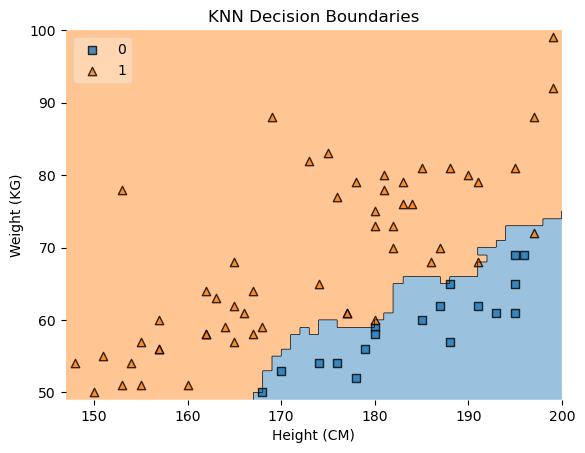

In [26]:
knn.fit(X_train.values, y_train.values)
plot_decision_regions(
    X_train.values,
    y_train.values,
    clf=knn,
    legend=2
)
plt.xlabel('Height (CM)')
plt.ylabel('Weight (KG)')
plt.title('KNN Decision Boundaries')
plt.show()

